# Session A : Speed Tuning

by Zhidong Zhang

In [1]:
%load_ext autoreload
%autoreload 2
from utils import *

data = load_data()
trial_data_dict = {stim: extract_trials(data, stimulus=stim) for stim in STIMULI}

## Compute analysis

In [2]:
tunings = {label: SpeedTuning(trial_data_dict[stim]) for (label, stim) in zip(SHORT_STIM, STIMULI)}

for stim in SHORT_STIM:
    tunings[stim].run()

In [3]:
# All stimuli
st_stimuli = SpeedTuning(trial_data_dict)
st_stimuli.run()
# Gratings
st_gratings = SpeedTuning({label: trial_data_dict[stim] for (label, stim) in zip(SHORT_STIM, STIMULI) if stim in ['drifting_gratings', 'static_gratings']})
st_gratings.run()

## Glance at the distribution of speed

The distribution of running speed is highly unbalanced!

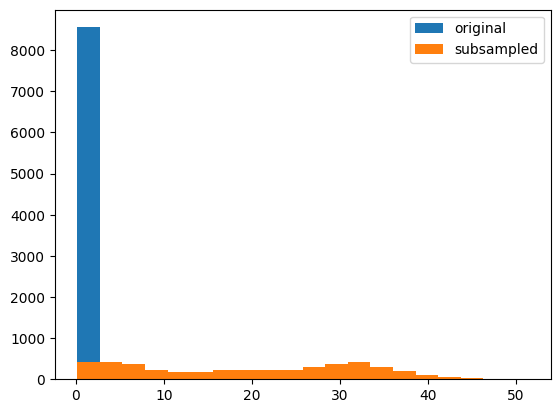

In [4]:
plt.hist(st_stimuli.speeds, bins=st_stimuli.bins_edges,label='original')
sub_speeds = st_stimuli.speeds[st_stimuli.bins_sub_ids!=-1]
plt.hist(sub_speeds, bins=st_stimuli.bins_edges,label='subsampled')
plt.legend()

## With stimuli vs Spontaneous

In [5]:
st_stimuli.print_tuned_cells()

Significantly tuned neurons: #15 
 [ 2  4  5  8 12 14 18 19 26 34 36 38 40 43 47]
Positive tuned neurons: #11 
 [ 2  4  5 12 14 18 26 36 38 43 47]
[0.11815153 0.06936879 0.02547183 0.05044089 0.03353328 0.03503375
 0.43956403 0.09516207 0.31465606 0.02836921 0.09005222]
Negative tuned neurons: #3 
 [ 8 34 40]
[-0.0235098  -0.02271405 -0.06053784]
Non-monotonic tuned neurons: #1 
 [19]
[0.00838951]


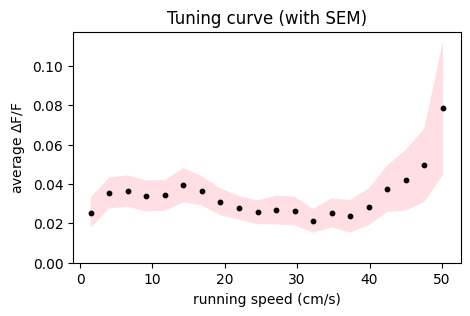

In [6]:
ax = st_stimuli.plot_tuning_curve(semcolor='pink')
ax.set_ylim(0)
ax.set_title("Tuning curve (with SEM)")
plt.show()

In [7]:
tunings['spont'].print_tuned_cells()

Significantly tuned neurons: #3 
 [26 36 38]
Positive tuned neurons: #2 
 [26 36]
[0.5380154  0.35931997]
Negative tuned neurons: #0 
 []
[]
Non-monotonic tuned neurons: #1 
 [38]
[0.10694379]


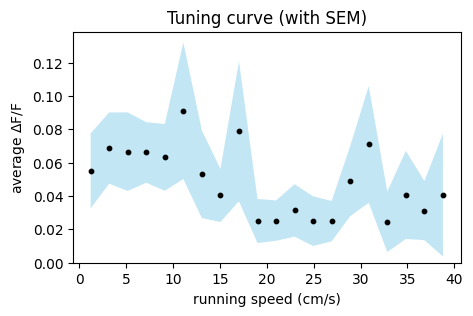

In [8]:
ax = tunings['spont'].plot_tuning_curve(semcolor='skyblue')
ax.set_ylim(0)
ax.set_title("Tuning curve (with SEM)")
plt.show()

<Axes: ylabel='# f significant neurons'>

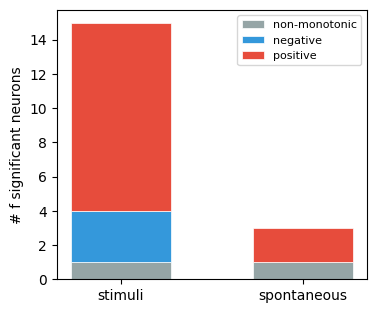

In [9]:
plot_monotonicity_stacked_bar({'stimuli': st_stimuli, 'spontaneous': tunings['spont']}, figsize=(4,3.5))  

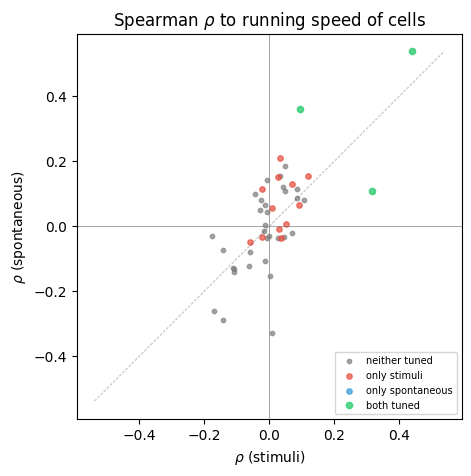

In [10]:
ax = plot_rho_pairwise_scatter(st_stimuli, tunings['spont'], 'stimuli', 'spontaneous')

## Different stimuli

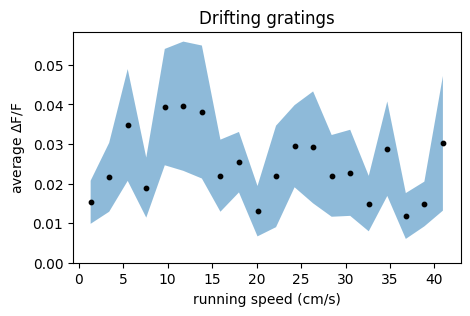

In [11]:
ax = tunings['dg'].plot_tuning_curve()
ax.set_title("Drifting gratings")
plt.show()

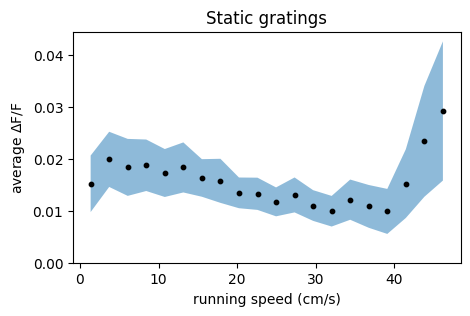

In [12]:
ax = tunings['sg'].plot_tuning_curve()
ax.set_title("Static gratings")
plt.show()

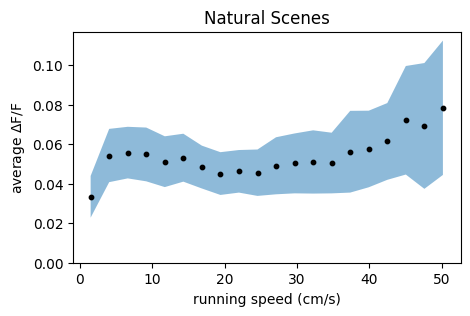

In [13]:
ax = tunings['ns'].plot_tuning_curve()
ax.set_title("Natural Scenes")
plt.show()

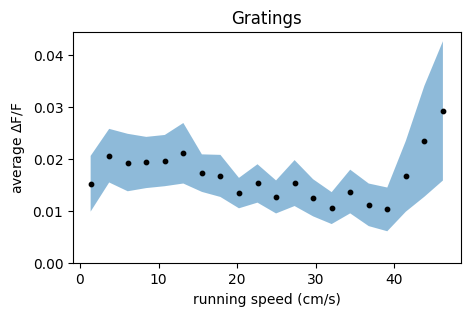

In [14]:
ax = st_gratings.plot_tuning_curve()
ax.set_title("Gratings")
plt.show()

<Axes: ylabel='# f significant neurons'>

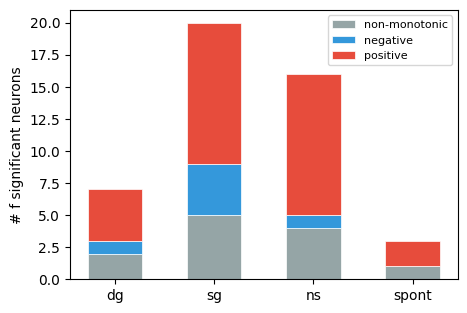

In [15]:
plot_monotonicity_stacked_bar(tunings)  

<Axes: ylabel='# f significant neurons'>

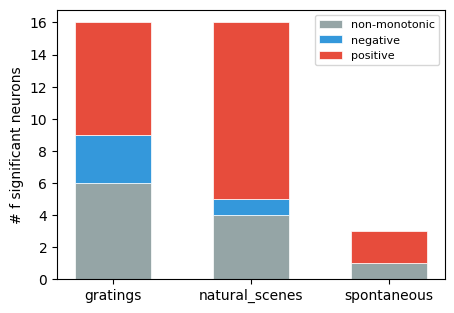

In [16]:
plot_monotonicity_stacked_bar({'gratings': st_gratings, 'natural_scenes': tunings['ns'], 'spontaneous': tunings['spont']})  

## Fractions

In [ ]:
df = pd.read_csv("data/neurons_metadata.csv", index_col=0)
p_stim = df[[f'p_{stim}' for stim in SHORT_STIM[:-1]]].values
print(p_stim.shape)
masking = p_stim < 0.05
np.sum(masking, axis=0)

(47, 3)


array([30, 43, 44])

In [ ]:
responsive = {stim: masking[:, i].T for (i, stim) in enumerate(SHORT_STIM[:-1])}
responsive

{'dg': array([False,  True,  True, False,  True,  True,  True, False,  True,
         True,  True, False,  True,  True,  True,  True,  True, False,
         True,  True,  True, False,  True, False,  True,  True,  True,
        False,  True, False, False,  True,  True,  True, False,  True,
         True,  True, False,  True,  True, False,  True, False, False,
        False, False]),
 'sg': array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True,  True, False,  True,
         True,  True]),
 'ns': array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False,  True,  True,  True,  True,  True,  True,  True,
         Tr

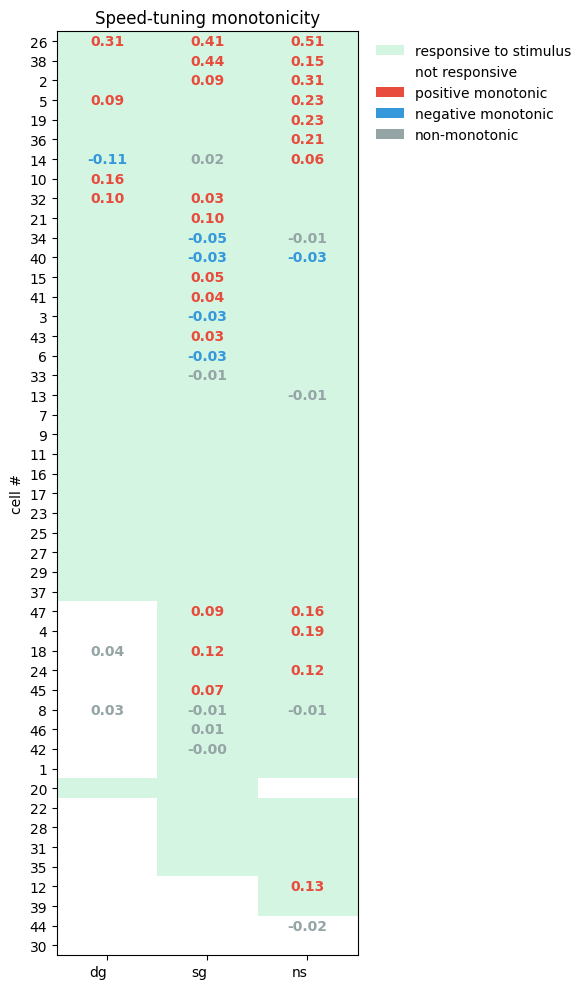

In [25]:
fig = plot_monotonicity_grid(tunings, responsive)
plt.show()

---